**ROAD ACCIDENT ANALYSIS**

**Name:** Sakina Gheewala

**Enrollment No.:** 0827CS231228

**Project Title:**
Road Accident Analysis  

**Objective:**
To analyze road accident data and identify patterns based on accident severity, weather conditions, road conditions, vehicle types, speed limits, and casualties.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Road Accident Data.csv to Road Accident Data.csv


In [2]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv('Road Accident Data.csv')

# Display basic information
print(df.shape)
print(df.info())

(307973, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Month                       307973 non-null  object 
 3   Day_of_Week                 307973 non-null  object 
 4   Year                        307973 non-null  int64  
 5   Junction_Control            307973 non-null  object 
 6   Junction_Detail             307973 non-null  object 
 7   Accident_Severity           307973 non-null  object 
 8   Latitude                    307973 non-null  float64
 9   Light_Conditions            307973 non-null  object 
 10  Local_Authority_(District)  307973 non-null  object 
 11  Carriageway_Hazards         5424 non-null    object 
 12  Longitude                   307973 non-null  float64
 13  N

Data Cleaning

Check Missing Values


In [3]:
df.isnull().sum()

,0
Accident_Index,0
Accident Date,0
Month,0
Day_of_Week,0
Year,0
Junction_Control,0
Junction_Detail,0
Accident_Severity,0
Latitude,0
Light_Conditions,0


Remove Duplicates

In [4]:
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

New Shape: (307972, 23)


Convert Date Column

In [5]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'])

df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,2021-01-01,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,2021-01-05,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,2021-01-04,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,2021-01-05,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,2021-01-06,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


Check Data Types

In [6]:
df.dtypes

,0
Accident_Index,object
Accident Date,datetime64[ns]
Month,object
Day_of_Week,object
Year,int64
Junction_Control,object
Junction_Detail,object
Accident_Severity,object
Latitude,float64
Light_Conditions,object


Correcting Data Type for Time column

In [12]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce')

In [13]:
# verify
df.dtypes

,0
Accident_Index,object
Accident Date,datetime64[ns]
Month,object
Day_of_Week,object
Year,int64
Junction_Control,object
Junction_Detail,object
Accident_Severity,object
Latitude,float64
Light_Conditions,object


In [7]:
df.describe()

,Accident Date,Year,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307972,307972.000000,307972.000000,307972.000000,307972.000000,307972.000000,307972.000000
mean,2021-12-23 22:21:18.537009664,2021.468935,52.487001,-1.368882,1.356883,1.829066,38.866001
min,2021-01-01 00:00:00,2021.000000,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,2021-06-28 00:00:00,2021.000000,51.485248,-2.247942,1.000000,1.000000,30.000000
50%,2021-12-08 00:00:00,2021.000000,52.225935,-1.349254,1.000000,2.000000,30.000000
75%,2022-06-25 00:00:00,2022.000000,53.415514,-0.206810,1.000000,2.000000,50.000000
max,2022-12-31 00:00:00,2022.000000,60.598055,1.759398,48.000000,32.000000,70.000000
std,NaN,0.499035,1.339011,1.356093,0.815858,0.710476,14.032942


Handling Missing Value

In [10]:
# Fill missing values with mode (most frequent value)
df['Carriageway_Hazards'].fillna(df['Carriageway_Hazards'].mode()[0], inplace=True)

df['Road_Surface_Conditions'].fillna(df['Road_Surface_Conditions'].mode()[0], inplace=True)

df['Road_Type'].fillna(df['Road_Type'].mode()[0], inplace=True)

df['Time'].fillna(df['Time'].mode()[0], inplace=True)

df['Weather_Conditions'].fillna(df['Weather_Conditions'].mode()[0], inplace=True)


In [11]:
# Verify again
print(df.isnull().sum())

Accident_Index                0
Accident Date                 0
Month                         0
Day_of_Week                   0
Year                          0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Carriageway_Hazards           0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64


The dataset contained missing values in Carriageway_Hazards,Road_Surface_Conditions, Road_Type, Time, and Weather_Conditions.

To preserve all records and avoid loss of information, missing values
were replaced with the mode (most frequently occurring value) of each
respective column.

After preprocessing, the dataset contained no missing values and was
ready for analysis and visualization.

**Data Visualization**

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.set_style("whitegrid")

<Figure size 1000x500 with 0 Axes>

Accident Severity Distribution

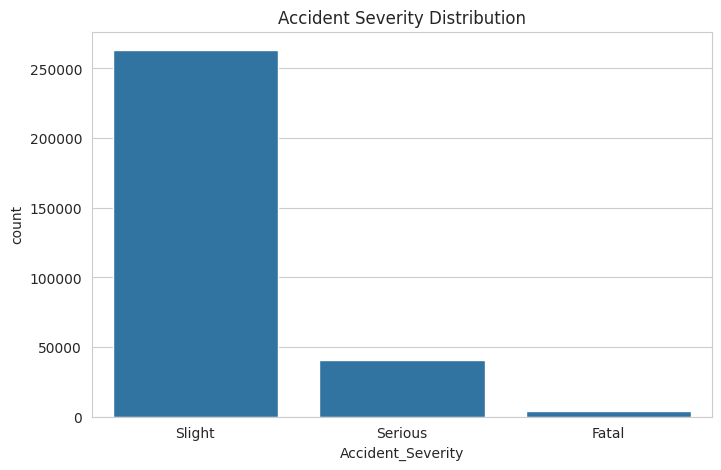

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Accident_Severity', data=df, order=df['Accident_Severity'].value_counts().index)
plt.title("Accident Severity Distribution")
plt.show()

Most accidents are Slight severity.
Serious accidents are fewer.
Fatal accidents are the least frequent.

Accidents by Weather Condition

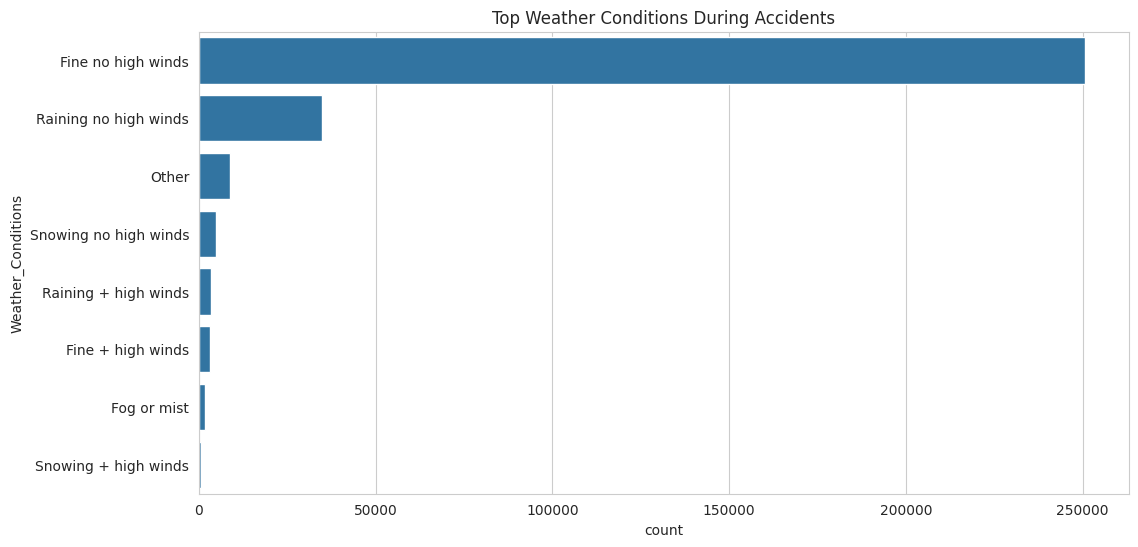

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(y='Weather_Conditions', data=df, order=df['Weather_Conditions'].value_counts().head(10).index)
plt.title("Top Weather Conditions During Accidents")
plt.show()

Most accidents occur during fine weather conditions.
Bad weather contributes to fewer accidents.

Road Surface Conditions

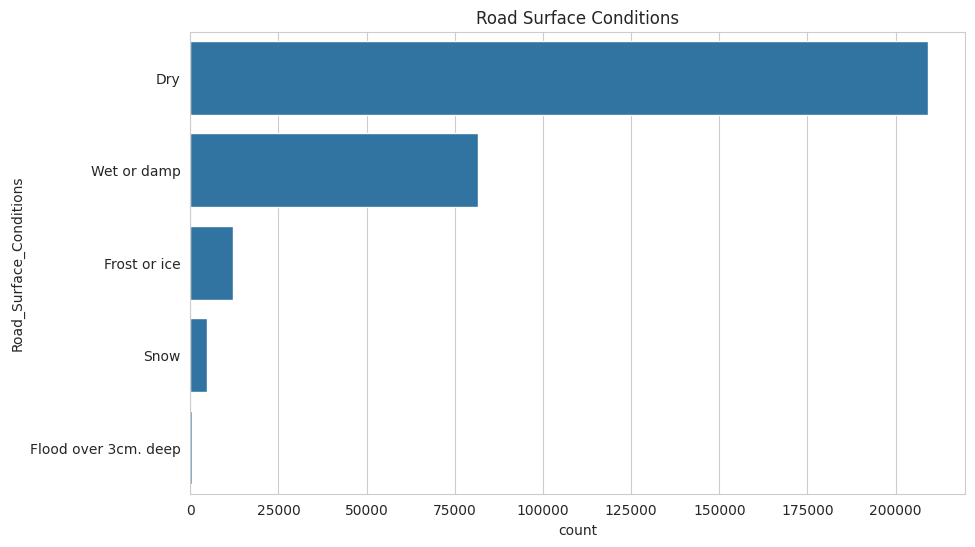

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(y='Road_Surface_Conditions', data=df, order=df['Road_Surface_Conditions'].value_counts().index)

plt.title("Road Surface Conditions")
plt.show()

Dry roads account for the majority of accidents.
Wet roads are the second most common condition.

Urban vs Rural Accidents

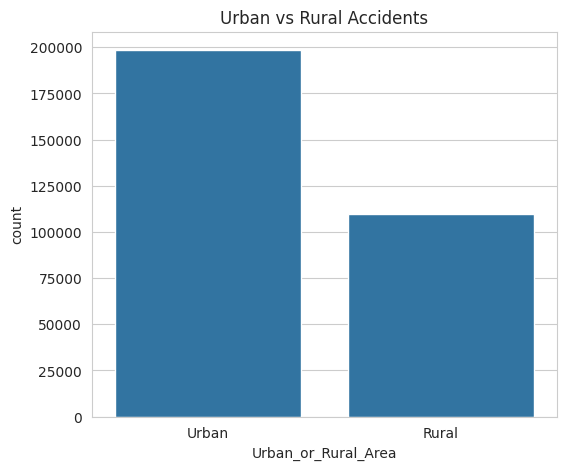

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(x='Urban_or_Rural_Area', data=df)
plt.title("Urban vs Rural Accidents")
plt.show()

Urban areas experience significantly more accidents than rural areas.

Vehicle Type Involved

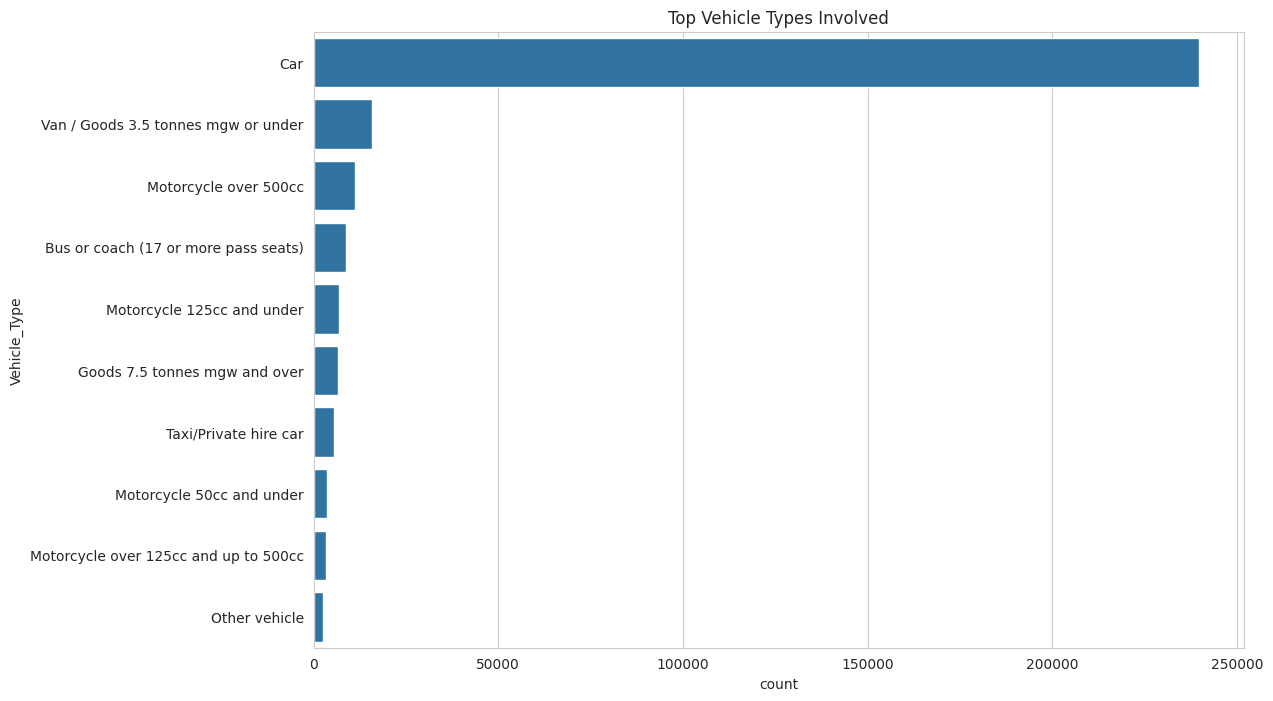

In [19]:
plt.figure(figsize=(12,8))
sns.countplot(y='Vehicle_Type', data=df, order=df['Vehicle_Type'].value_counts().head(10).index)
plt.title("Top Vehicle Types Involved")
plt.show()

Cars are involved in most accidents.
Motorcycles and taxis also contribute significantly.

Speed Limit Analysis

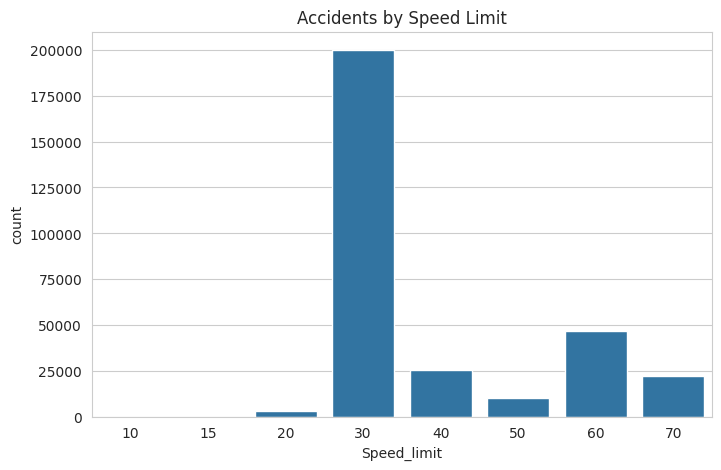

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Speed_limit', data=df, order=sorted(df['Speed_limit'].unique()))
plt.title("Accidents by Speed Limit")
plt.show()

Most accidents occur in 30 mph zones.

Casualties Distribution

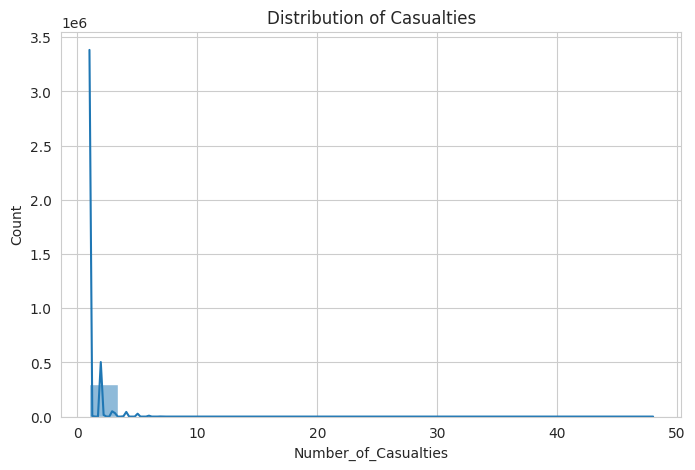

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Number_of_Casualties'],bins=20,kde=True)
plt.title("Distribution of Casualties")
plt.show()

Most accidents result in one casualty.
High casualty accidents are rare.

Monthly Accident Trend

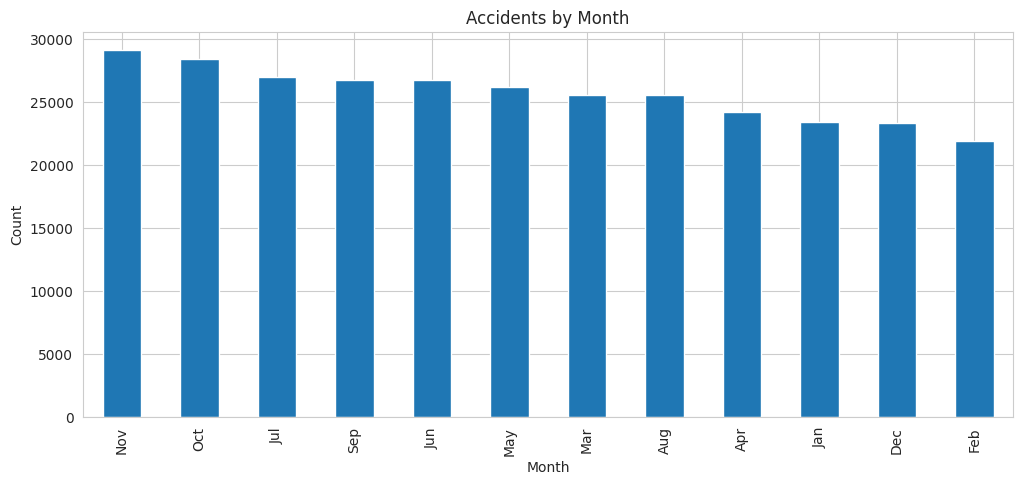

In [22]:
monthly_accidents = df['Month'].value_counts()
plt.figure(figsize=(12,5))
monthly_accidents.plot(kind='bar')
plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

Accidents vary throughout the year.
Some months show noticeably higher accident frequencies.

Day Wise Accident Analysis

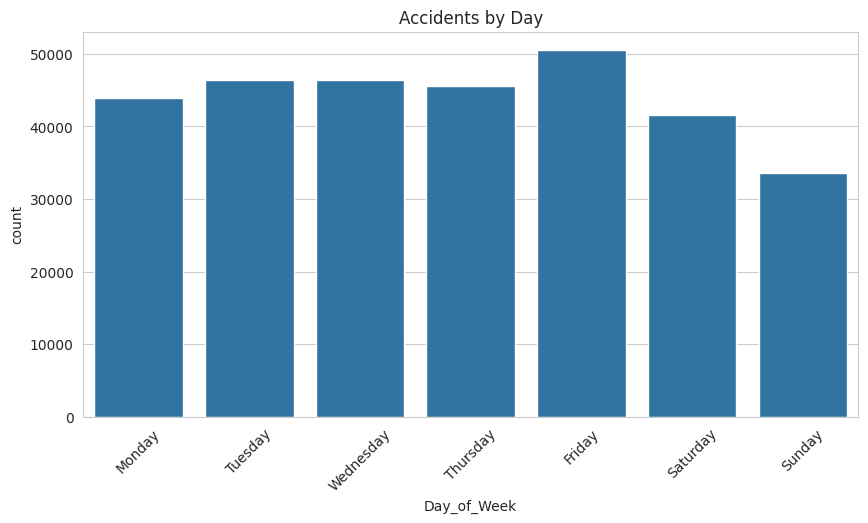

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(x='Day_of_Week',data=df, order=['Monday','Tuesday','Wednesday','Thursday',
           'Friday','Saturday','Sunday'])
plt.xticks(rotation=45)
plt.title("Accidents by Day")
plt.show()

Weekdays generally have more accidents due to traffic volume.

Correlation Heatmap

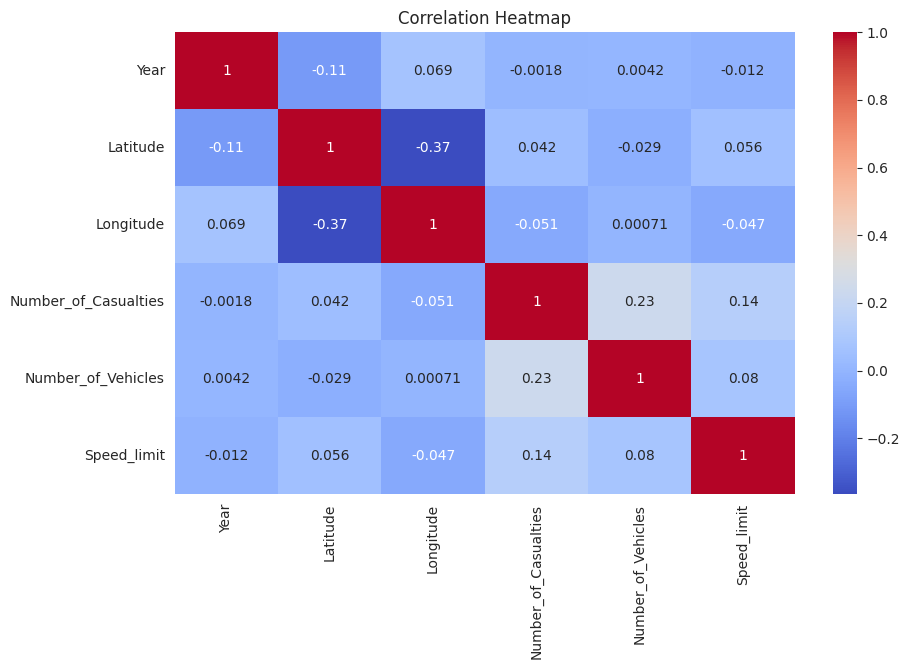

In [24]:
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Number of vehicles and casualties show positive correlation.

Monthly Accident Trend

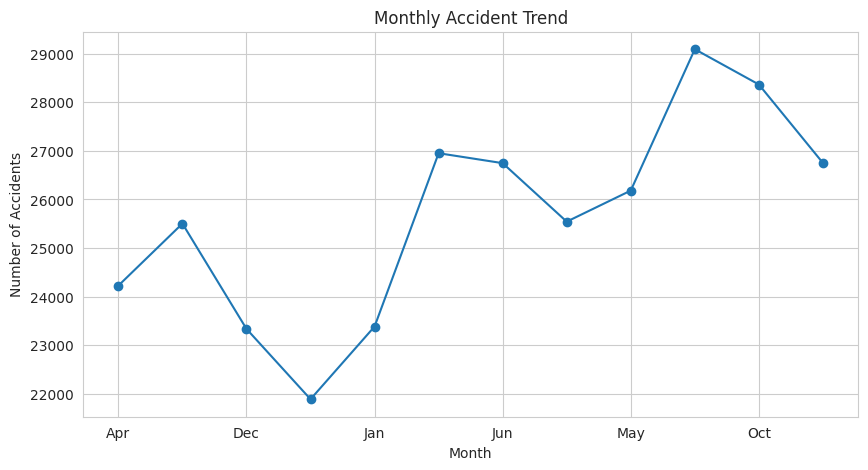

In [25]:
monthly_accidents = df.groupby('Month').size()
plt.figure(figsize=(10,5))
monthly_accidents.plot(kind='line',marker='o')
plt.title('Monthly Accident Trend')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.grid(True)

plt.show()

The line chart shows how accident frequency changes across different months. Peaks indicate months with higher accident occurrences, while dips represent relatively safer periods.

Accidents by Hour of the Day

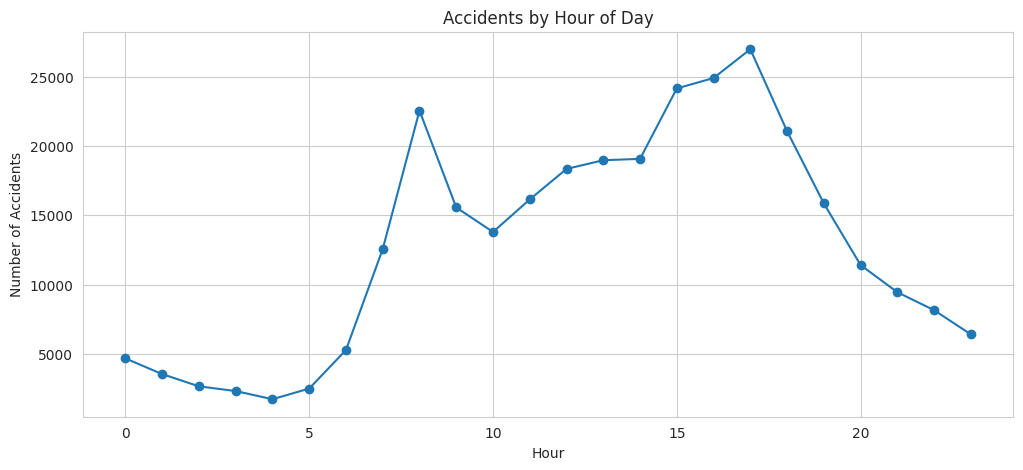

In [26]:
df['Hour'] = df['Time'].dt.hour
hourly_accidents = df.groupby('Hour').size()
plt.figure(figsize=(12,5))
hourly_accidents.plot(kind='line',marker='o')
plt.title('Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

The chart identifies peak accident hours during the day. Accident frequency is generally higher during commuting hours due to increased traffic volume.

**KEY INSIGHTS**

1. The majority of road accidents were classified as Slight accidents, while Fatal accidents were comparatively rare.

2. Urban areas recorded a significantly higher number of accidents than rural areas, indicating increased traffic density and congestion.

3. Most accidents occurred under fine weather conditions, suggesting that traffic volume may have a greater impact on accidents than adverse weather.

4. Dry road surfaces were associated with the highest number of accidents, as they represent the most common driving conditions.

5. Cars were the vehicle type most frequently involved in road accidents, followed by other commonly used vehicles.

6. The highest number of accidents occurred in areas with a speed limit of 30 mph, indicating that accident frequency is strongly related to traffic volume in urban regions.

7. Most accidents resulted in only one casualty, while accidents involving multiple casualties were relatively uncommon.

8. Analysis of accident timing showed that accident frequency varies throughout the day, with peak periods generally occurring during busy traffic hours.

9. Monthly trends indicated that accident occurrences fluctuate over time, suggesting seasonal and traffic-related influences.

10. Geographic attributes such as latitude and longitude can be further utilized for location-based accident hotspot identification.


**CONCLUSION**

The Road Accident Analysis project was conducted to examine accident patterns and identify factors associated with road accidents. The dataset was cleaned by handling missing values, verifying data types, and ensuring data quality before analysis.

The analysis revealed that most accidents were of slight severity and occurred in urban areas. Cars were the most frequently involved vehicle type, and accidents were most common on dry roads and in regions with a 30 mph speed limit. Time-based analysis showed that accident occurrences vary throughout the day, while monthly trends indicated fluctuations in accident frequency over the year.

Overall, the findings suggest that road safety initiatives should focus on high-traffic urban areas, peak travel hours, and awareness programs for drivers. The insights obtained from this analysis can help transportation authorities and policymakers make informed decisions to improve road safety and reduce accident risks.
